In [ ]:
# ==============================================
# EXP 6: CREDIT RISK ASSESSMENT
# Models: Logistic Regression, Random Forest, XGBoost
# ==============================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
# ----------------------------------------------
# Step 2: Load Dataset
# ----------------------------------------------
data = pd.read_csv("/content/drive/MyDrive/ML LAB EXPERIMENTS/credit_risk_assessment_500_samples.csv")

print("First 5 Rows:")
print(data.head())

print("\nDataset Info:")
print(data.info())


First 5 Rows:
   Applicant_ID  Age  Annual_Income  Employment_Years  Credit_Score  \
0             1   59         153267                28           818   
1             2   49         232745                 0           436   
2             3   35         974945                19           797   
3             4   63         307164                29           776   
4             5   28         685626                 6           893   

   Loan_Amount  Loan_Term_Months  Existing_Loans_Count  Debt_to_Income_Ratio  \
0       196649                12                     2                  0.68   
1       175354                60                     0                  0.23   
2       662297                48                     3                  0.54   
3       831725                48                     0                  0.56   
4       498625                60                     3                  0.66   

   Late_Payments_Last_2Yrs Credit_Risk  
0                        0        Hig

In [ ]:
# ----------------------------------------------
# Step 3: Data Preprocessing
# ----------------------------------------------

# Drop duplicate rows if any
data = data.drop_duplicates()

# Handle missing values (fill numerical with median)
data = data.fillna(data.median(numeric_only=True))

# Separate features and target
# Assuming target column is named 'Credit_Risk'
X = data.drop("Credit_Risk", axis=1)
y = data["Credit_Risk"]

# Convert categorical variables (if any)
X = pd.get_dummies(X, drop_first=True)

In [ ]:
# ----------------------------------------------
# Step 4: Train-Test Split
# ----------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
# ----------------------------------------------
# Step 5: Feature Scaling (important for Logistic Regression)
# ----------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# ----------------------------------------------
# Step 6: Model Training
# ----------------------------------------------

# Encode target labels to numerical values for models that require it (like XGBoost)
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# 1️⃣ Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train_encoded)

# 2️⃣ Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train_encoded)

# 3️⃣ XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss') # Use mlogloss for multi-class
xgb_model.fit(X_train, y_train_encoded)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:02:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# ----------------------------------------------
# Step 7: Predictions
# ----------------------------------------------
log_pred = log_model.predict(X_test_scaled)
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

# Probability scores (for ROC)
# Modify to get probabilities for all classes for multi-class ROC curve
log_prob = log_model.predict_proba(X_test_scaled)
rf_prob = rf_model.predict_proba(X_test)
xgb_prob = xgb_model.predict_proba(X_test)

In [ ]:
# ----------------------------------------------
# Step 8: Evaluation Function
# ----------------------------------------------
def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n{name} Performance:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall:", recall_score(y_true, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))

# Evaluate All Models
evaluate_model("Logistic Regression", y_test_encoded, log_pred, log_prob)
evaluate_model("Random Forest", y_test_encoded, rf_pred, rf_prob)
evaluate_model("XGBoost", y_test_encoded, xgb_pred, xgb_prob)


Logistic Regression Performance:
Accuracy: 0.84
Precision: 0.8373701298701297
Recall: 0.84
F1 Score: 0.8364478551751279

Random Forest Performance:
Accuracy: 0.96
Precision: 0.9617079530638852
Recall: 0.96
F1 Score: 0.9541404794036373

XGBoost Performance:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


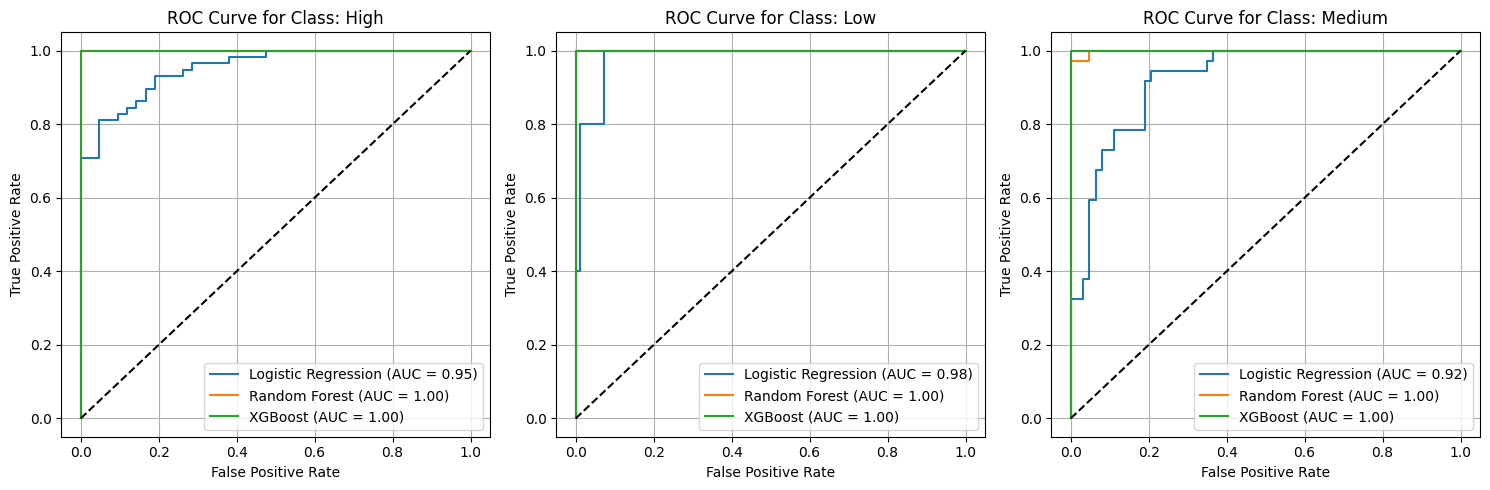

In [ ]:
# ----------------------------------------------
# Step 9: ROC Curve Comparison (Multiclass - One-vs-Rest approach)
# ----------------------------------------------

# Ensure y_test_encoded is available and models' predict_proba returns full probability arrays
# (these should already be correctly populated from cell qBV5j5RbRqsu)

plt.figure(figsize=(15, 5)) # Adjusted figure size to accommodate multiple subplots

n_classes = len(label_encoder.classes_)

models_prob = {
    "Logistic Regression": log_prob,
    "Random Forest": rf_prob,
    "XGBoost": xgb_prob
}

for i, class_name in enumerate(label_encoder.classes_):
    plt.subplot(1, n_classes, i + 1)
    plt.title(f'ROC Curve for Class: {class_name}')

    # Binarize y_test_encoded for the current class (One-vs-Rest)
    y_test_binarized = (y_test_encoded == i).astype(int)

    for model_name, prob_scores in models_prob.items():
        # Ensure the probability scores are 2D for multiclass OvR
        if prob_scores.ndim != 2 or prob_scores.shape[1] != n_classes:
            print(f"Error: {model_name} probabilities are not in the expected 2D format for OvR. Skipping.")
            continue

        fpr, tpr, _ = roc_curve(y_test_binarized, prob_scores[:, i])
        roc_auc = roc_auc_score(y_test_binarized, prob_scores[:, i])
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--') # Random guess line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ----------------------------------------------
# Step 10: Save Models in Google Drive
# ----------------------------------------------

# First mount drive (only if not already mounted)
from google.colab import drive
drive.mount('/content/drive')

# Define save path
save_path = "/content/drive/MyDrive/ML LAB EXPERIMENTS/"

# Save models
pickle.dump(log_model, open(save_path + "logistic_model.pkl", "wb"))
pickle.dump(rf_model, open(save_path + "random_forest_model.pkl", "wb"))
pickle.dump(xgb_model, open(save_path + "xgboost_model.pkl", "wb"))

print("\nModels saved successfully in Google Drive!")

MessageError: Error: credential propagation was unsuccessful